<a href="https://colab.research.google.com/github/saworx/CDS-Forecast/blob/main/Wind_Turbine_ADH_Data_Python_Library.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# get_ipython().magic(u'config IPCompleter.greedy=True')

In [ ]:
#Google Driveへマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ADHクライアントをインストール
!pip install adh_sample_library_preview

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 110 kB 35.4 MB/s 
     |████████████████████████████████| 62 kB 1.4 MB/s 
  Attempting uninstall: requests
    Found existing installation: requests 2.23.0
    Uninstalling requests-2.23.0:
      Successfully uninstalled requests-2.23.0


In [ ]:
import requests
import configparser
import json
import pandas as pd
from datetime import date, timedelta
from adh_sample_library_preview import *

numberOfPreviewRows = 5 #各ステップで出力される行数を５行とする

In [ ]:
config = configparser.ConfigParser()
config.read('/content/drive/MyDrive/Colab Notebooks/configADH.ini')

ADHClient = ADHClient(config.get('Access', 'ApiVersion'), config.get('Access', 'Tenant'), config.get('Access', 'Resource'), config.get('Credentials', 'ClientId'), config.get('Credentials', 'ClientSecret'))

namespaceId = config.get('Configurations', 'Namespace')
namespaceId

'63a7020f-e047-4279-8dea-c71d36df747d'

# 新しいセクション

In [ ]:
dateFrom = '2022-05-03'
dateTo ='2022-05-04'
#dateFrom = 'Mar 11, 2021, 12:00:00 AM' #str(date.today()-timedelta(days=10))
#dateTo = 'Mar 12, 2021, 12:00:00 AM'# str(date.today()) #10 days of data
timeinterval = '00:01:00' #インターバル：１分間隔にする

#dataviewId = Wind Turbine Data_NN, where NN is your specific student number (e.g. NN=01 in this example)
dataviewId= "Wind Turbine Asset View"

#data, n, f = ocsClient.DataViews.getDataInterpolated(namespace_id=namespaceId, dataView_id=dataviewId, count=150000,startIndex=dateFrom, endIndex=dateTo, interval=timeinterval)
data, n, f = ADHClient.DataViews.getDataInterpolated(namespace_id=namespaceId, data_view_id=dataviewId, count=150000,start_index=dateFrom, end_index=dateTo, interval=timeinterval)

# アウトプット (but truncate it after a handful of rows)
data[:numberOfPreviewRows]



[{'Active Power Value': 929.53674,
  'Apparent Power Value': 930.4667364984454,
  'Auto Stop Reason Value': 4,
  'Availability Flag Value': 1,
  'Bearing A Temperature Value': 42.144135,
  'Bearing B Temperature Value': 69.66527,
  'Blade1, Actual Value Value': 1.0423063,
  'Blade1, Set Value Value': 2.6285536,
  'Blade2, Actual Value Value': 2.123454,
  'Blade2, Set Value Value': 2.6285536,
  'Blade3, Actual Value Value': 0.12147273,
  'Blade3, Set Value Value': 2.6285536,
  'Capacity Value': 47.712772,
  'Circut Breaker Cut-Ins Value': 4201.867,
  'Current L1 Value': 960.2731,
  'Current L2 Value': 958.7349,
  'Current L3 Value': 949.00006,
  'Curtailment Aggregation_Revenue Value': -58.171902844304874,
  'Drive Train Acceleration Value': 179.11514,
  'EAF Value': 98.31481100745388,
  'Energy Delta - Hourly Value': -0.12687298622592463,
  'Energy Production - Daily Predicted Value': 17.401542333984377,
  'Energy Production - Daily Value': 14.909840751013224,
  'Energy Production - Ho

# データフレーム投入

In [ ]:
# データフレーム定義
df = pd.DataFrame(data)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df[:numberOfPreviewRows]


,Timestamp,Name,Active Power Value,Apparent Power Value,Auto Stop Reason Value,Availability Flag Value,Bearing A Temperature Value,Bearing B Temperature Value,"Blade1, Actual Value Value","Blade1, Set Value Value",...,"Torque, Actual Value Value","Torque, Set Value Value",Tower Acceleration Value,Tower Deflection Value,Vacuum - External Oil Heater Value,Wind Deviation 10s Value,Wind Deviation 1s Value,Wind Speed - 10 min rolling avg Value,Wind Speed Value,Wind Farm
0,2022-05-03 00:00:00,GE01 Wind Turbine,929.53674,930.466736,4,1,42.144135,69.665270,1.042306,2.628554,...,63.108536,64.097590,134.094420,2417.7110,-47.998505,25.885567,37.070858,8.985616,10.206483,Big Buffalo Wind Farm
1,2022-05-03 00:01:00,GE01 Wind Turbine,1442.53600,1444.013030,4,1,42.151880,69.693600,2.268948,3.459832,...,94.800026,95.698140,97.812836,2417.6814,-47.998627,34.875570,27.796623,8.996490,12.461610,Big Buffalo Wind Farm
2,2022-05-03 00:02:00,GE01 Wind Turbine,891.07570,891.515278,4,1,42.159626,69.721940,-0.431898,-0.320991,...,59.093246,59.277985,69.111664,2417.6516,-47.998753,-36.866444,-11.257367,9.007365,9.688463,Big Buffalo Wind Farm
3,2022-05-03 00:03:00,GE01 Wind Turbine,715.65170,716.136289,4,1,42.167370,69.750275,0.006235,0.555937,...,49.564808,50.776466,58.386383,2417.6220,-47.998880,9.029029,-5.464428,9.018239,9.517141,Big Buffalo Wind Farm
4,2022-05-03 00:04:00,GE01 Wind Turbine,643.56104,644.099052,4,1,42.175114,69.778610,0.444367,1.432865,...,47.010020,47.213090,45.974102,2417.5923,-47.999000,-44.705406,-43.046220,9.029114,7.778400,Big Buffalo Wind Farm


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#カラム名を略称にして、次の相関関係の表を見やすくする

df.rename(columns = {'Blade 1 Position':'BL1', 'Blade 2 Position':'BL2',
                     'Blade 3 Position':'BL3', 'Rotor Speed Value':'RS','Turbine':'TS',
                     'Active Power Value':'AP', 'Nacelle Position Value':'NP', 'Air Temperature Value':'AT',
                     'Operating State':'OS', 'Operating Efficiency':'OE', 'Nacelle Temperature':'NT',
                     'Gearbox Temperature':'GB','Wind Speed':'WS'}, inplace = True)

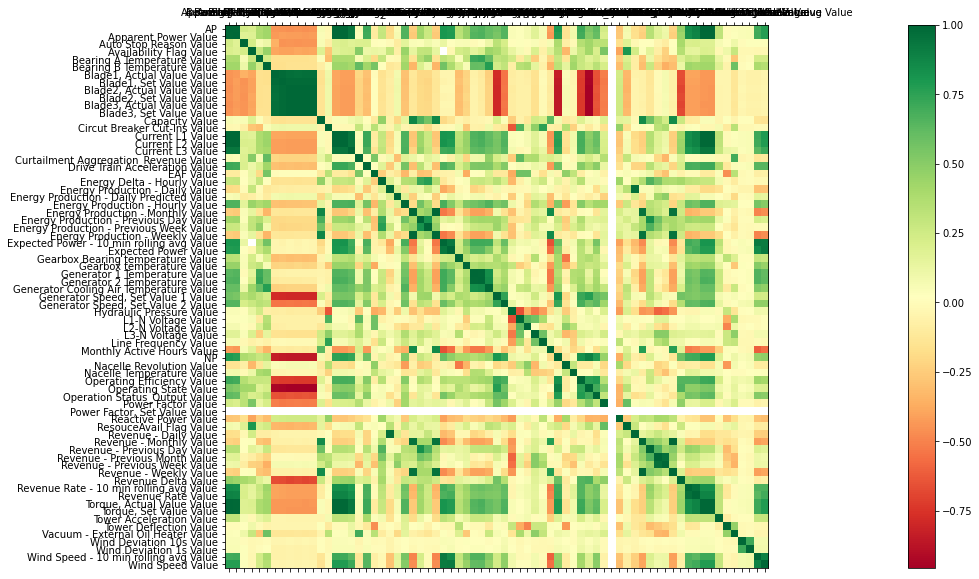

In [ ]:
#発電量と他の変数との相関を確認する

#相関テーブル作成
df_corr = df.corr()

#図のサイズ拡張
fig = plt.figure(figsize=(50,10))
ax = fig.add_subplot(111)

#カラーパレットセット (Red, yellow, green)
cax = ax.matshow(df_corr, cmap=plt.cm.RdYlGn)
fig.colorbar(cax)

#ラベル設定
labels = [c for c in df_corr.columns]

#すべてのラベルを表示
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

#相関図のxとyにラベルを設定
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.show(block=False)

In [ ]:
#ラベルを戻す

df.rename(columns = {'BL1':'Blade1', 'BL2':'Blade2',
                     'BL3':'Blade3', 'RS':'Rotor Speed Value','TS':'Turbine',
                     'AP':'Active Power Value','NP':'Nacelle Position Value', 'AT':'Air Temperature Value',
                     'OS':'Operating State', 'WS':'Wind Speed Value'}, inplace = True)

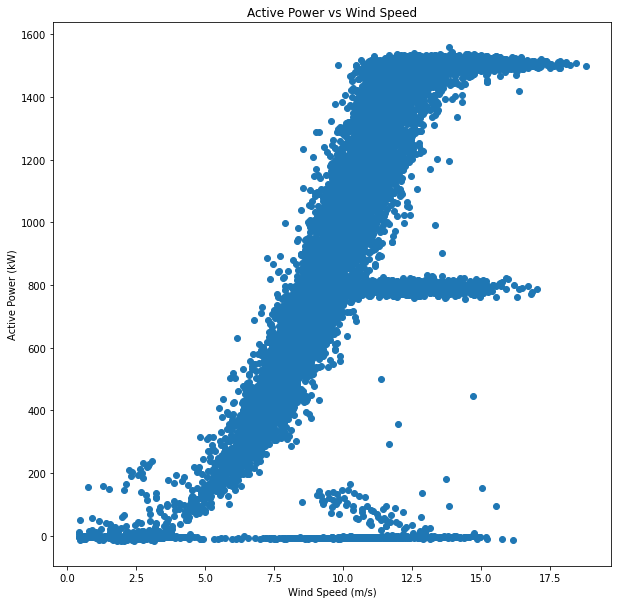

In [ ]:
#発電量と風速のプロット

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.scatter(df['Wind Speed Value'], df['Active Power Value'])
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Active Power (kW)')
ax.set_title('Active Power vs Wind Speed')

plt.show(block=False)

In [ ]:

# df = df.dropna() #not needed
#GE05タービンは、他のすべてのタービンに比べて評価が低いため、データフレームから列を削除する
filterOutGE05 = df['Name'] != "GE05 Wind Turbine"
df_Filter = df[filterOutGE05]

In [ ]:
#Active Powerの負の値や過剰な値をフィルタリング
filterNegativeActivePower = (df_Filter['Active Power Value'] >= 0)
df_Filter = df_Filter[filterNegativeActivePower]


In [ ]:
#通常の動作条件のみを維持するために、風速が高く、アクティブパワーが低い行を削除
filterOutLowPowerHighWindSpeedData = (~((df_Filter['Wind Speed Value'] >  10) & (df_Filter['Active Power Value'] <600)))
df_Filter = df_Filter[filterOutLowPowerHighWindSpeedData]

In [ ]:
#Load Operation(Stateが16)の状態に対応する行のみを残す
filterLoadOperationState = df_Filter['Operating State Value'] == 16
df_Filter = df_Filter[filterLoadOperationState]

In [ ]:
#アクティブパワーの結果に影響を与えない高い風速（> 13 m/s）をフィルタリング
filterOutHighWind = df_Filter['Wind Speed Value'] <13
df_Filter = df_Filter[filterOutHighWind]

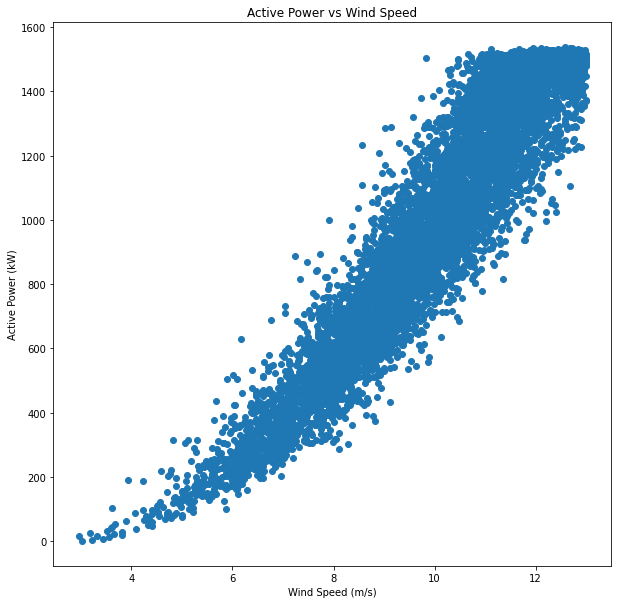

In [ ]:
#Active Power と Wind Speedをプロット - 通常の動作条件を示すフィルタリングされたデータフレーム

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.scatter(df_Filter['Wind Speed Value'], df_Filter['Active Power Value'])
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Active Power (kW)')
ax.set_title('Active Power vs Wind Speed')

plt.show(block=False)

In [ ]:
#Air Temperatureに欠損値があるので、省く
df_Filter.isnull()
#df_Filter.isnull().sum()
df_Clear = df_Filter.dropna()
df_Clear.isnull().sum()

Timestamp                                0
Name                                     0
Active Power Value                       0
Apparent Power Value                     0
Auto Stop Reason Value                   0
                                        ..
Wind Deviation 10s Value                 0
Wind Deviation 1s Value                  0
Wind Speed - 10 min rolling avg Value    0
Wind Speed Value                         0
Wind Farm                                0
Length: 74, dtype: int64

In [ ]:
#トレーニングデータセットとテスト/スコアリングデータセットを用意し、ランダムに分割する
from sklearn.model_selection import train_test_split
#予測対象となる変数の定義
y = df_Clear['Active Power Value'].values
#データセットをテストセットとトレーニングセットにランダムに分割
X_train, X_test, y_train, y_test = train_test_split(df_Clear[['Generator Cooling Air Temperature Value', 'Wind Speed Value']].values,
                                                    y, test_size=0.25, random_state=42)


#print(X_train)
#print(X_test)
#print(y_train)
#print(y_test)

In [ ]:
#scikit-learnの決定木回帰機械学習モデル(the Decision Tree Regression Machine Learning model)を使用
from sklearn.tree import DecisionTreeRegressor
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X_train, y_train)
regr_2.fit(X_train, y_train)

# Predict
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

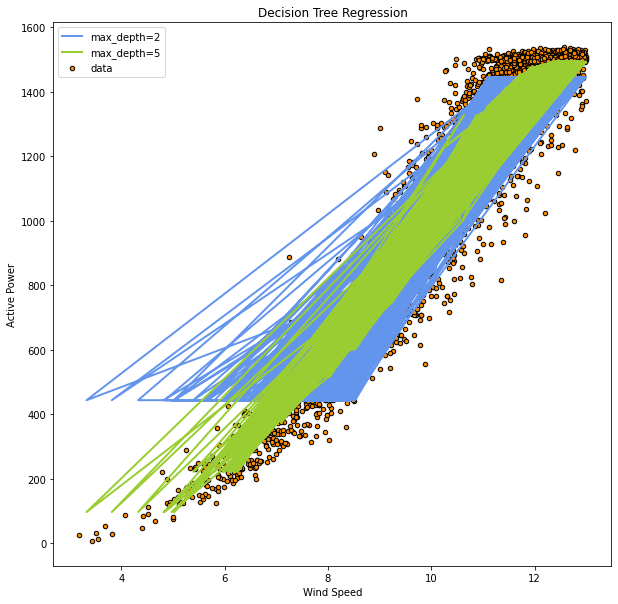

In [ ]:
# 結果をプロット
plt.figure(figsize=(10,10))
plt.scatter(X_train[:,1], y_train, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test[:,1], y_1, color="cornflowerblue",label="max_depth=2", linewidth=2)
plt.plot(X_test[:,1], y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("Wind Speed")
plt.ylabel("Active Power")
plt.title("Decision Tree Regression")
plt.legend()
plt.show(block=False)

In [ ]:
#機械学習モデルをディスクにセーブ
import pickle
filename = 'WT_ActivePower_model.sav'
pickle.dump(regr_2, open(filename, 'wb'))

In [ ]:
#スコアリング・テスト用モデルのテスト
loaded_model = pickle.load(open(filename, 'rb'))
global result
result = loaded_model.score(X_test, y_test)
#print the model score
print(result)

0.9312178862992686


In [ ]:
#サンプルの予測
# define input
new_input = [[45, 6.6]] #Temp=45 F, Wind Speed = 6.6 m/s
# 新規の予測計算
new_output = regr_2.predict(new_input)
print(new_output)

[308.77085544]


In [ ]:
#OpenWeather APIを呼び出して、Amarillo, TXの向こう5日間の気温と風速の予測値を取得
import requests
url="https://api.openweathermap.org/data/2.5/forecast?q=Amarillo,US&APPID=5dac981ce33f41f61d8d1ea06ee89798"
responseWeatherForecast=requests.get(url)

In [ ]:
responseWeatherForecast.json()

{'city': {'coord': {'lat': 35.222, 'lon': -101.8313},
  'country': 'US',
  'id': 5516233,
  'name': 'Amarillo',
  'population': 190695,
  'sunrise': 1659182084,
  'sunset': 1659232355,
  'timezone': -18000},
 'cnt': 40,
 'cod': '200',
 'list': [{'clouds': {'all': 0},
   'dt': 1659236400,
   'dt_txt': '2022-07-31 03:00:00',
   'main': {'feels_like': 301.44,
    'grnd_level': 895,
    'humidity': 64,
    'pressure': 1019,
    'sea_level': 1019,
    'temp': 300.09,
    'temp_kf': 0.12,
    'temp_max': 300.09,
    'temp_min': 299.97},
   'pop': 0,
   'sys': {'pod': 'n'},
   'visibility': 10000,
   'weather': [{'description': 'clear sky',
     'icon': '01n',
     'id': 800,
     'main': 'Clear'}],
   'wind': {'deg': 144, 'gust': 12.28, 'speed': 8.04}},
  {'clouds': {'all': 23},
   'dt': 1659247200,
   'dt_txt': '2022-07-31 06:00:00',
   'main': {'feels_like': 299.6,
    'grnd_level': 895,
    'humidity': 61,
    'pressure': 1018,
    'sea_level': 1018,
    'temp': 299.6,
    'temp_kf': 0.98

In [ ]:
#APIのjsonレスポンスから予測された気温、風速、タイムスタンプをpandas DataFrameに格納

from decimal import Decimal
import datetime
TempArray = []
WindSpeedArray = []
TimestampArray = []

for val in responseWeatherForecast.json()["list"]:
    tempKelvin = val["main"]["temp"]
    tempF = round(((tempKelvin - 273.15) * (9/5)) + 32, 2)
    windSpeedMeterPerSec = round(val["wind"]["speed"], 2)
    np.array(TempArray.append(tempF))
    np.array(WindSpeedArray.append(windSpeedMeterPerSec))
    np.array(TimestampArray.append(datetime.datetime.strptime(val["dt_txt"], '%Y-%m-%d %H:%M:%S')))

dfWeatherForecast = pd.DataFrame({'Timestamp':TimestampArray, '温度 (F)':TempArray, '風速 (m/s)':WindSpeedArray})

dfWeatherForecast[:numberOfPreviewRows]

,Timestamp,温度 (F),風速 (m/s)
0,2022-07-31 03:00:00,80.49,8.04
1,2022-07-31 06:00:00,79.61,6.44
2,2022-07-31 09:00:00,76.50,3.80
3,2022-07-31 12:00:00,73.78,4.17
4,2022-07-31 15:00:00,84.54,8.95


In [ ]:
#開発した機械学習モデルを使用して、発電量を予測し、その値を既存のデータフレームに追加

import pickle
filename = 'WT_ActivePower_model.sav'
loaded_model = pickle.load(open(filename, 'rb'))

PredictedPowerArray=[]

for index, row in dfWeatherForecast.iterrows():
    new_input = [[row['温度 (F)'], row['風速 (m/s)']]]
    result = loaded_model.predict(new_input)
    np.array(PredictedPowerArray.append(result))

dfWeatherForecast['発電予測 (kW)']=pd.DataFrame(PredictedPowerArray)

dfWeatherForecast[:numberOfPreviewRows]

,Timestamp,温度 (F),風速 (m/s),発電予測 (kW)
0,2022-07-31 03:00:00,80.49,8.04,685.830340
1,2022-07-31 06:00:00,79.61,6.44,308.770855
2,2022-07-31 09:00:00,76.50,3.80,96.587316
3,2022-07-31 12:00:00,73.78,4.17,96.587316
4,2022-07-31 15:00:00,84.54,8.95,833.482654


In [ ]:
#気温、風速、予測される有効電力、時間のタイプを作成

typeId = "Wind_Turbine_Predictions_Time"

typeTempWindPowerTime = SdsType(
    typeId,
    SdsTypeCode.Object,
    description="A Time-Series indexed type with 3 values")

#このタイプは、doubleとdatetimeの2つのデータ型を使用
doubleType = SdsType("doubleType", SdsTypeCode.Double)
timeType = SdsType("string", SdsTypeCode.DateTime)

#This type has three double properties and one datetime
airTempProp = SdsTypeProperty("Air_Temperature", sds_type=doubleType)
windSpeedProp = SdsTypeProperty("Wind_Speed", sds_type=doubleType)
predActPowerProp = SdsTypeProperty("Predicted_Active_Power", sds_type=doubleType)
timeProp = SdsTypeProperty("Timestamp", True, timeType)

#Add the properties to the type, and commit it to ADH
typeTempWindPowerTime.Properties = [airTempProp, windSpeedProp, predActPowerProp, timeProp]

ADHClient.Types.getOrCreateType(namespaceId, typeTempWindPowerTime)


In [ ]:
#Create the stream based on the previously created type

streamId = "WT_5dForecast_1"

predPowerStream = SdsStream(
    streamId,
    typeId,
    description="A stream for predicted active power data")

#Commit the stream to OCS
ADHClient.Streams.getOrCreateStream(namespaceId, predPowerStream)

In [ ]:
#Save data back to prediction stream in OCS

values = []

for index, row in dfWeatherForecast.iterrows():
        values.append({"Air_Temperature": row["Temp (F)"], "Wind_Speed": row["Wind Speed (m/s)"],
                       "Predicted_Active_Power": row["Predicted Active Power (kW)"], "Timestamp":
                       row["Timestamp"].strftime('%Y-%m-%d %H:%M:%S') })

ADHClient.Streams.updateValues(namespaceId, streamId, json.dumps(values))
global finished
finished = True

In [ ]:
def test_result():
    global result

    assert result is not None

def test_finished():
    global finished

    assert finished
